In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lecture (le comment='#' vire les textes inutiles au début)
df = pd.read_csv('data/SH_MTN002037002.csv', sep=';', comment='#')

# 2. Nettoyage automatique des noms de colonnes (vire les espaces)
df.columns = df.columns.str.strip()

# 3. Création d'une vraie colonne Date
# On transforme '195901' en une date que Python comprend
df['DATE'] = pd.to_datetime(df['YYYYMM'].astype(str), format='%Y%m')

# 4. Conversion de la valeur (si c'est en 1/10ème d'unité)
# Vérifie si tu dois diviser par 10 ou pas selon ton fichier
df['VALEUR_PROPRE'] = df['VALEUR'] 

print("✅ Nettoyage terminé !")
df.head()

Matplotlib is building the font cache; this may take a moment.


FileNotFoundError: [Errno 2] No such file or directory: 'data/SH_MTN002037002.csv'

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 5)

In [7]:
import glob

# Trouve le premier fichier
fichier_test = glob.glob('data/**/*.csv', recursive=True)[0]
print(f"📄 Fichier : {fichier_test}\n")

# Affiche les 20 premières lignes brutes
with open(fichier_test, 'r', encoding='latin-1') as f:
    for i, ligne in enumerate(f):
        print(f"Ligne {i:2d} | {ligne}", end='')
        if i >= 20:
            break

📄 Fichier : data/vigieau_arretes_2024.csv

Ligne  0 | id,numero,date_debut,date_signature,date_fin,statut,departement,chemin_fichier,niveau_gravite_specifique_aep,ressource_aep_communique,arrete_cadre.id,arrete_cadre.numero,arrete_cadre.date_debut,arrete_cadre.date_fin,arrete_cadre.chemin_fichier,zones_alerte.id,zones_alerte.type,zones_alerte.code,zones_alerte.nom,zones_alerte.niveau_gravite,zones_alerte.id_sandre,regle_gestion,zones_alerte.communes
Ligne  1 | 34627,DDT-BIEF-2023-321-0003 du 17 novembre (ACD LB)),2023-11-18,2023-11-17,2024-01-27,abroge,48,https://regleau.s3.gra.perf.cloud.ovh.net//arrete-restriction/34627/AP7_DDT-BIEF-2023-321-0003_17novembre2023_RAA.odt.pdf,null,null,30330,ACD LB DDT-BIEF 2023-199-0002_18/07/2023,2023-07-20,2024-05-22,https://regleau.s3.gra.perf.cloud.ovh.net//arrete-cadre/30330/AP_DDT_BIEF_2023-199-0002_18072023_VF_RAAcomplet.pdf,"[10954,10956,10955,10953]","[""SUP"",""SUP"",""SUP"",""SUP""]","[""76_48_0010"",""76_48_0012"",""76_48_0011"",""76_48_000

In [6]:
def lire_fichier_meteo(filepath):
    """
    Lit un fichier CSV Météo France qui a des lignes # en en-tête
    Retourne un DataFrame propre
    """
    with open(filepath, 'r', encoding='latin-1') as f:
        lignes = f.readlines()
    
    # Trouve la première ligne qui n'est pas un commentaire
    debut = 0
    for i, ligne in enumerate(lignes):
        if not ligne.startswith('#'):
            debut = i
            break
    
    # Relit proprement à partir de l'en-tête
    df = pd.read_csv(
        filepath,
        sep=';',
        skiprows=debut,
        encoding='latin-1'
    )
    
    # Renomme les colonnes pour plus de clarté
    df.columns = df.columns.str.strip()
    
    # Convertit YYYYMM en vrai datetime
    df['DATE'] = pd.to_datetime(df['YYYYMM'].astype(str), format='%Y%m')
    df['ANNEE'] = df['DATE'].dt.year
    df['MOIS'] = df['DATE'].dt.month
    
    # Remplace les valeurs manquantes (souvent -9999 chez Météo France)
    df['VALEUR'] = pd.to_numeric(df['VALEUR'], errors='coerce')
    df.loc[df['VALEUR'] < -999, 'VALEUR'] = None
    
    return df

# Test sur un fichier
fichier_test = glob.glob('data/**/*.csv', recursive=True)[0]
df_test = lire_fichier_meteo(fichier_test)
print(f"✅ {fichier_test}")
print(df_test.head())
print(f"Période : {df_test['DATE'].min()} → {df_test['DATE'].max()}")

KeyError: 'YYYYMM'

In [8]:
import glob

fichiers = glob.glob('data/**/*.csv', recursive=True)
for f in fichiers:
    print(f)

data/vigieau_arretes_2024.csv
data/stations-meteo-france.csv
data/ch4_mm_gl.csv
data/ademe_projections_4c.csv
data/co2_mm_mlo.csv
data/sdes_ges_namea.csv
data/ademe_projections_2c.csv
data/co2_mm_gl.csv
data/explore2_vcn10_region.csv
data/n2o_mm_gl.csv
data/SH_TX_metropole/SH_MTX276217001.csv
data/SH_TX_metropole/SH_MTX386027001.csv
data/SH_TX_metropole/SH_MTX287106001.csv
data/SH_TX_metropole/SH_MTX044117002.csv
data/SH_TX_metropole/SH_MTX203204001.csv
data/SH_TX_metropole/SH_MTX163223001.csv
data/SH_TX_metropole/SH_MTX226307001.csv
data/SH_TX_metropole/SH_MTX181124001.csv
data/SH_TX_metropole/SH_MTX026324001.csv
data/SH_TX_metropole/SH_MTX236208001.csv
data/SH_TX_metropole/SH_MTX369204002.csv
data/SH_TX_metropole/SH_MTX285216001.csv
data/SH_TX_metropole/SH_MTX104019001.csv
data/SH_TX_metropole/SH_MTX246127001.csv
data/SH_TX_metropole/SH_MTX269264001.csv
data/SH_TX_metropole/SH_MTX171491001.csv
data/SH_TX_metropole/SH_MTX220041001.csv
data/SH_TX_metropole/SH_MTX450020001.csv
data/SH_T

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def lire_co2_noaa(filepath):
    """Lit un fichier CO2 NOAA en ignorant les lignes de commentaires #"""
    with open(filepath, 'r') as f:
        lignes = f.readlines()
    
    # Trouve la ligne d'en-tête (première sans #)
    debut = 0
    for i, ligne in enumerate(lignes):
        if not ligne.startswith('#'):
            debut = i
            break
    
    df = pd.read_csv(filepath, skiprows=debut)
    df.columns = df.columns.str.strip()
    return df

# Charge les deux fichiers — adapte les noms si besoin
df_maunaloa = lire_co2_noaa('data/co2_mm_mlo.csv')   # Mauna Loa (depuis 1958)
df_global   = lire_co2_noaa('data/co2_mm_gl.csv')    # Global (depuis 1979)

print("=== Mauna Loa ===")
print(df_maunaloa.columns.tolist())
print(df_maunaloa.head(2))

print("\n=== Global ===")
print(df_global.columns.tolist())
print(df_global.head(2))

=== Mauna Loa ===
['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays', 'sdev', 'unc']
   year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0  1958      3     1958.2027   315.71          314.44     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99

=== Global ===
['year', 'month', 'decimal', 'average', 'average_unc', 'trend', 'trend_unc']
   year  month   decimal  average  average_unc   trend  trend_unc
0  1979      1  1979.042   336.56         0.11  335.92       0.09
1  1979      2  1979.125   337.29         0.09  336.26       0.09


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def lire_noaa(filepath, nom_gaz, unite):
    with open(filepath, 'r') as f:
        lignes = f.readlines()
    
    debut = 0
    for i, ligne in enumerate(lignes):
        if not ligne.startswith('#') and ligne.strip() != '':
            debut = i
            break
    
    df = pd.read_csv(filepath, skiprows=debut)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={'average': 'valeur'})
    
    df['DATE'] = pd.to_datetime(
        df['year'].astype(str) + '-' + df['month'].astype(str),
        format='%Y-%m'
    )
    # Nettoie les valeurs manquantes NOAA
    df.loc[df['valeur'] < 0, 'valeur'] = None
    
    df['gaz']   = nom_gaz
    df['unite'] = unite
    
    return df[['DATE', 'year', 'month', 'valeur', 'gaz', 'unite']]


# Charge les 3 fichiers — adapte les noms si besoin
df_co2 = lire_noaa('data/co2_mm_gl.csv', 'CO2',  'ppm')
df_ch4 = lire_noaa('data/ch4_mm_gl.csv', 'CH4',  'ppb')
df_n2o = lire_noaa('data/n2o_mm_gl.csv', 'N2O',  'ppb')

# Combine en une seule table "longue"
df_ges = pd.concat([df_co2, df_ch4, df_n2o], ignore_index=True).sort_values(['gaz', 'DATE'])

print(f"✅ Table combinée : {len(df_ges)} lignes")
print(f"\nRésumé par gaz :")
print(df_ges.groupby('gaz').agg(
    debut=('DATE', 'min'),
    fin=('DATE', 'max'),
    nb_mois=('valeur', 'count'),
    derniere_valeur=('valeur', 'last')
).to_string())


✅ Table combinée : 1372 lignes

Résumé par gaz :
         debut        fin  nb_mois  derniere_valeur
gaz                                                
CH4 1983-07-01 2025-11-01      509          1945.85
CO2 1979-01-01 2025-12-01      564           427.35
N2O 2001-01-01 2025-11-01      299           339.46


In [11]:
# Format large : une ligne par date, une colonne par gaz
df_large = df_ges.pivot_table(
    index='DATE', 
    columns='gaz', 
    values='valeur'
).reset_index()

df_large.columns.name = None  # Enlève le nom de l'index
df_large = df_large.rename(columns={
    'CO2': 'CO2_ppm',
    'CH4': 'CH4_ppb',
    'N2O': 'N2O_ppb'
})

# Sauvegarde
df_large.to_csv('data/ges_combines.csv', index=False)

print("✅ Table large sauvegardée → data/ges_combines.csv")
print(f"   Période commune : {df_large.dropna()['DATE'].min()} → {df_large.dropna()['DATE'].max()}")
print(f"   {len(df_large.dropna())} mois avec les 3 gaz disponibles")
df_large.tail(5)

✅ Table large sauvegardée → data/ges_combines.csv
   Période commune : 2001-01-01 00:00:00 → 2025-11-01 00:00:00
   299 mois avec les 3 gaz disponibles


,DATE,CH4_ppb,CO2_ppm,N2O_ppb
559,2025-08-01,1930.61,423.04,338.88
560,2025-09-01,1939.45,423.15,338.99
561,2025-10-01,1946.16,424.72,339.21
562,2025-11-01,1945.85,426.47,339.46
563,2025-12-01,NaN,427.35,NaN


/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/425791240.py:41: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/425791240.py:41: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/425791240.py:41: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/425791240.py:42: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('data/ges_3gaz.png', dpi=150)
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/425791240.py:42: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.savefig('data/ges_3gaz.png', dpi=150)
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/i

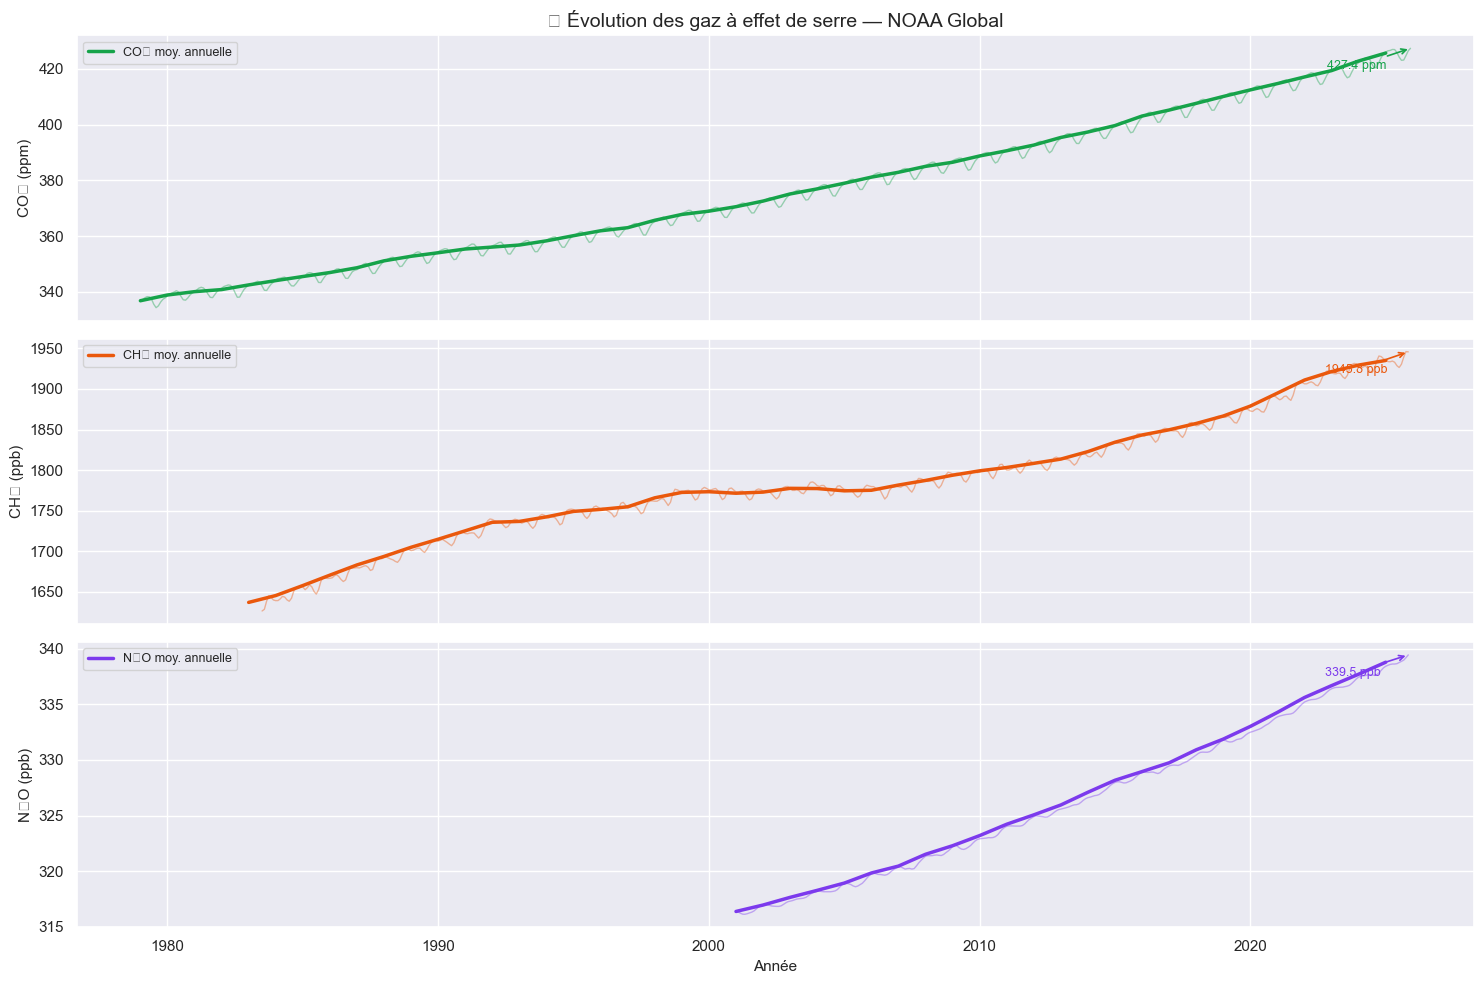

✅ Graphique sauvegardé → data/ges_3gaz.png


In [12]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

configs = [
    ('CO2_ppm', 'CO₂',  '#16a34a', 'ppm'),
    ('CH4_ppb', 'CH₄',  '#ea580c', 'ppb'),
    ('N2O_ppb', 'N₂O',  '#7c3aed', 'ppb'),
]

for ax, (col, label, couleur, unite) in zip(axes, configs):
    donnees = df_large.dropna(subset=[col])
    
    # Courbe mensuelle
    ax.plot(donnees['DATE'], donnees[col],
            color=couleur, linewidth=1, alpha=0.4)
    
    # Moyenne annuelle
    ann = donnees.copy()
    ann['year'] = ann['DATE'].dt.year
    ann_moy = ann.groupby('year')[col].mean().reset_index()
    ax.plot(
        pd.to_datetime(ann_moy['year'].astype(str)),
        ann_moy[col],
        color=couleur, linewidth=2.5, label=f'{label} moy. annuelle'
    )
    
    ax.set_ylabel(f'{label} ({unite})', fontsize=11)
    ax.legend(loc='upper left', fontsize=9)
    
    # Valeur actuelle en annotation
    derniere = donnees[col].dropna().iloc[-1]
    ax.annotate(f'{derniere:.1f} {unite}',
                xy=(donnees['DATE'].iloc[-1], derniere),
                xytext=(-60, -15), textcoords='offset points',
                fontsize=9, color=couleur,
                arrowprops=dict(arrowstyle='->', color=couleur, lw=1.2))

axes[0].set_title('🌍 Évolution des gaz à effet de serre — NOAA Global', fontsize=14)
axes[2].set_xlabel('Année', fontsize=11)

plt.tight_layout()
plt.savefig('data/ges_3gaz.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé → data/ges_3gaz.png")

/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: G

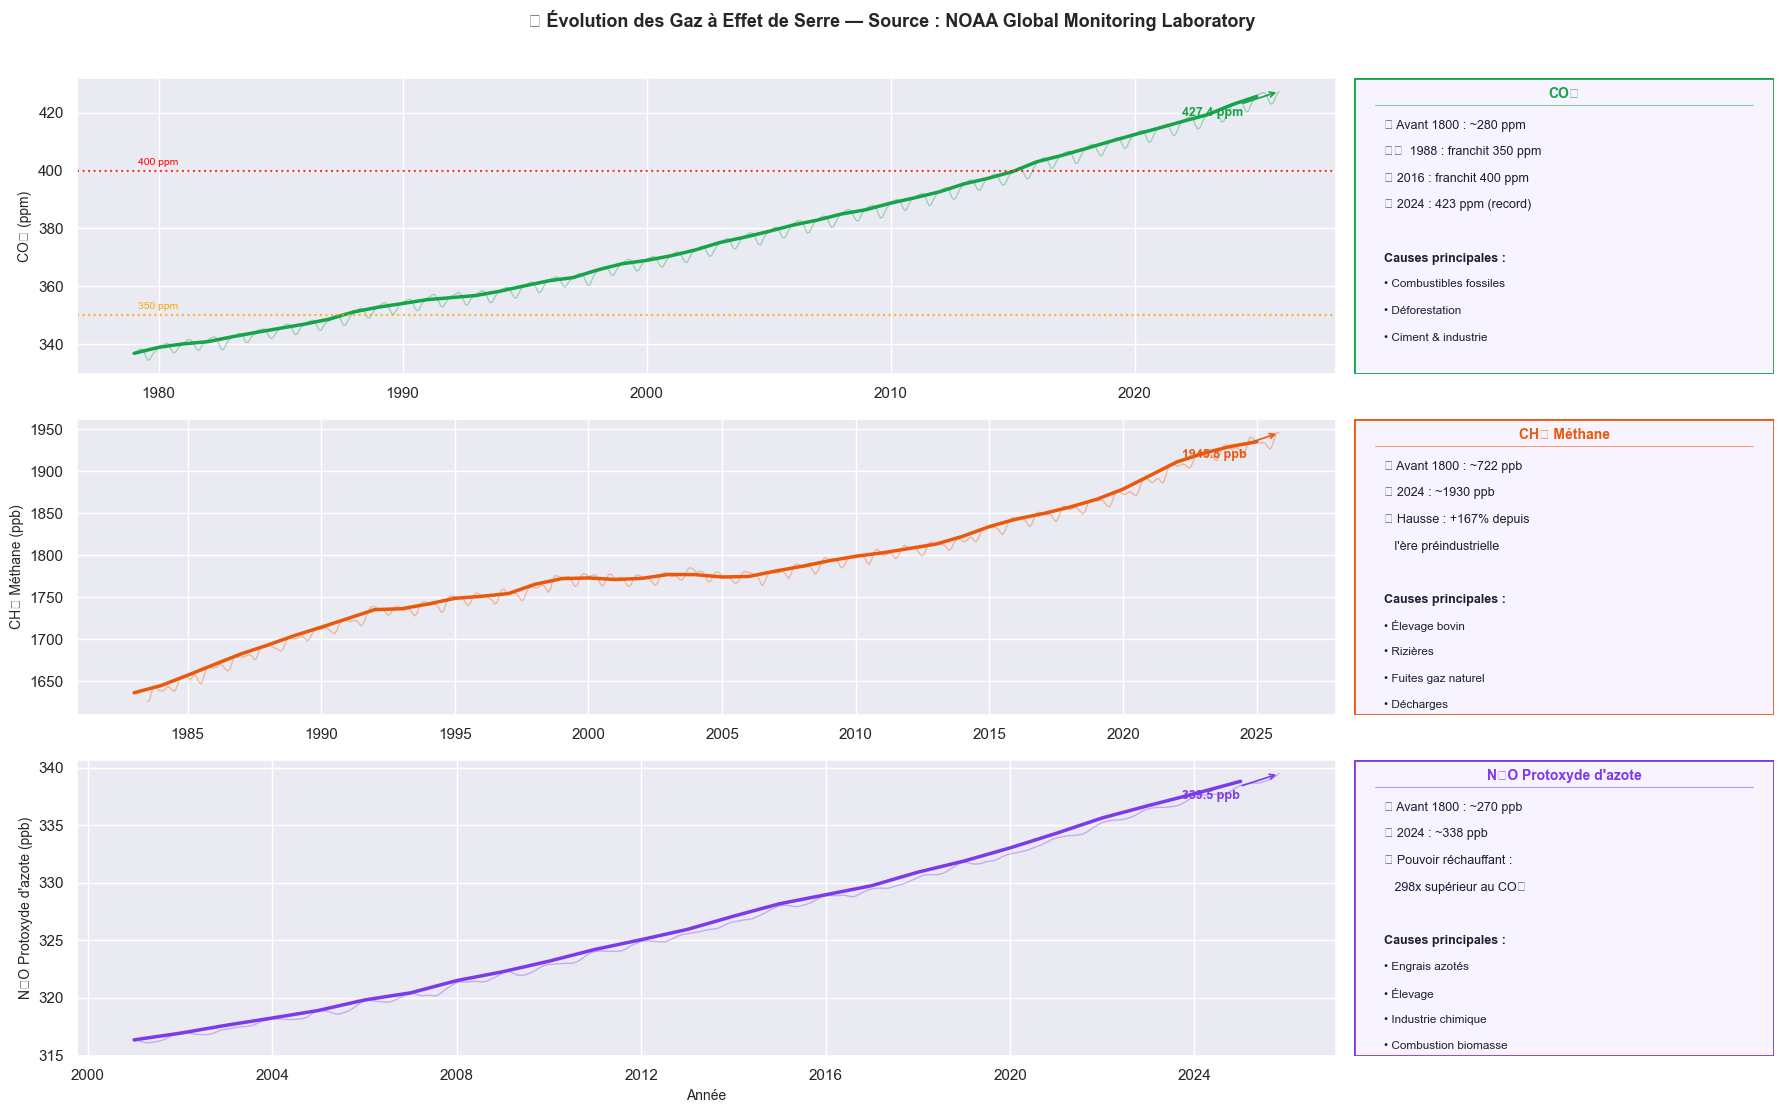

✅ Sauvegardé → data/ges_3gaz_contexte.png


In [14]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 11),
                          gridspec_kw={'width_ratios': [3, 1]})

configs = [
    ('CO2_ppm', 'CO₂', '#16a34a', 'ppm', [
        "🌿 Avant 1800 : ~280 ppm",
        "⚠️  1988 : franchit 350 ppm",
        "🚨 2016 : franchit 400 ppm",
        "📍 2024 : 423 ppm (record)",
        "",
        "Causes principales :",
        "• Combustibles fossiles",
        "• Déforestation",
        "• Ciment & industrie",
    ]),
    ('CH4_ppb', 'CH₄ Méthane', '#ea580c', 'ppb', [
        "🌿 Avant 1800 : ~722 ppb",
        "📍 2024 : ~1930 ppb",
        "📈 Hausse : +167% depuis",
        "   l'ère préindustrielle",
        "",
        "Causes principales :",
        "• Élevage bovin",
        "• Rizières",
        "• Fuites gaz naturel",
        "• Décharges",
    ]),
    ('N2O_ppb', 'N₂O Protoxyde d\'azote', '#7c3aed', 'ppb', [
        "🌿 Avant 1800 : ~270 ppb",
        "📍 2024 : ~338 ppb",
        "⚡ Pouvoir réchauffant :",
        "   298x supérieur au CO₂",
        "",
        "Causes principales :",
        "• Engrais azotés",
        "• Élevage",
        "• Industrie chimique",
        "• Combustion biomasse",
    ]),
]

for i, (col, label, couleur, unite, contexte) in enumerate(configs):
    ax_graph = axes[i][0]
    ax_text  = axes[i][1]

    # ── Graphique ──
    donnees = df_large.dropna(subset=[col])
    ax_graph.plot(donnees['DATE'], donnees[col],
                  color=couleur, linewidth=1, alpha=0.35)
    
    ann = donnees.copy()
    ann['year'] = ann['DATE'].dt.year
    ann_moy = ann.groupby('year')[col].mean().reset_index()
    ax_graph.plot(
        pd.to_datetime(ann_moy['year'].astype(str)),
        ann_moy[col],
        color=couleur, linewidth=2.5
    )

    # Seuils CO2
    if col == 'CO2_ppm':
        ax_graph.axhline(350, color='orange', linestyle=':', linewidth=1.5, alpha=0.8)
        ax_graph.axhline(400, color='red',    linestyle=':', linewidth=1.5, alpha=0.8)
        ax_graph.text(donnees['DATE'].iloc[2], 352, '350 ppm', fontsize=7.5, color='orange')
        ax_graph.text(donnees['DATE'].iloc[2], 402, '400 ppm', fontsize=7.5, color='red')

    # Annotation dernière valeur
    derniere = donnees[col].dropna().iloc[-1]
    ax_graph.annotate(
        f'{derniere:.1f} {unite}',
        xy=(donnees['DATE'].iloc[-1], derniere),
        xytext=(-70, -18), textcoords='offset points',
        fontsize=9, color=couleur, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=couleur, lw=1.2)
    )

    ax_graph.set_ylabel(f'{label} ({unite})', fontsize=10)
    if i == 2:
        ax_graph.set_xlabel('Année', fontsize=10)

    # ── Panneau texte ──
    ax_text.axis('off')
    ax_text.set_facecolor('#f8f4ff')

    # Cadre coloré
    rect = plt.Rectangle((0, 0), 1, 1,
                           transform=ax_text.transAxes,
                           facecolor='#f8f4ff',
                           edgecolor=couleur, linewidth=2)
    ax_text.add_patch(rect)

    # Titre du panneau
    ax_text.text(0.5, 0.97, label,
                 transform=ax_text.transAxes,
                 fontsize=10, fontweight='bold', color=couleur,
                 ha='center', va='top')

# Ligne séparatrice
    ax_text.axhline(y=0.91, xmin=0.05, xmax=0.95,
                    color=couleur, linewidth=0.8, alpha=0.5)

    # Texte de contexte
    y_pos = 0.86
    for ligne in contexte:
        style = 'bold' if ligne.startswith('Causes') else 'normal'
        size  = 8.5 if ligne.startswith('•') or ligne == '' else 9
        ax_text.text(0.07, y_pos, ligne,
                     transform=ax_text.transAxes,
                     fontsize=size, fontstyle='normal',
                     fontweight=style,
                     color='#1e1e2e', va='top')
        y_pos -= 0.09

# ── Titre global ──
fig.suptitle(
    '🌍 Évolution des Gaz à Effet de Serre — Source : NOAA Global Monitoring Laboratory',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('data/ges_3gaz_contexte.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé → data/ges_3gaz_contexte.png")